In [19]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Primeros 5 datos:
   Celsius  Fahrenheit
0      -50       -58.0
1      -40       -40.0
2      -30       -22.0
3      -20        -4.0
4      -10        14.0


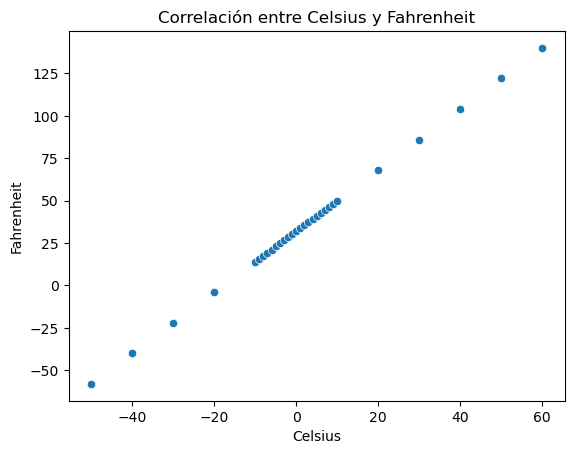

In [20]:
df_temperatura = pd.read_csv('celsius_a_fahrenheit.csv')

print("Primeros 5 datos:")
print(df_temperatura.head())

sns.scatterplot(x='Celsius', y='Fahrenheit', data=df_temperatura)
plt.title('Correlación entre Celsius y Fahrenheit')
plt.show()

Entrenando modelo simple...


c:\Users\marco\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


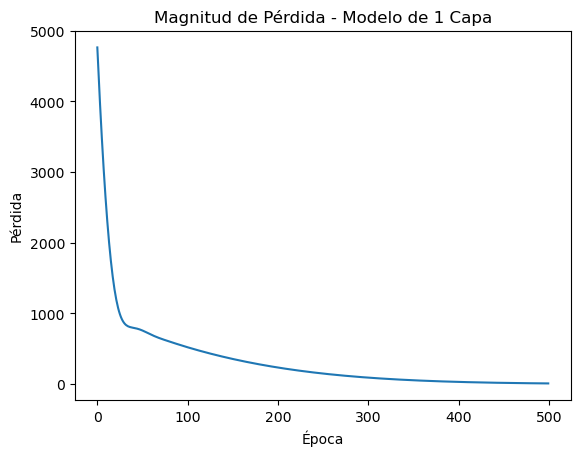

In [21]:
capa_simple = tf.keras.layers.Dense(units=1, input_shape=[1])
modelo_simple = tf.keras.Sequential([capa_simple])

modelo_simple.compile(
    optimizer=tf.keras.optimizers.Adam(0.1),
    loss='mean_squared_error'
)

print("Entrenando modelo simple...")
historial_simple = modelo_simple.fit(df_temperatura['Celsius'], df_temperatura['Fahrenheit'], epochs=500, verbose=False)

plt.plot(historial_simple.history['loss'])
plt.title('Magnitud de Pérdida - Modelo de 1 Capa')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.show()

c:\Users\marco\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando modelo multicapa...


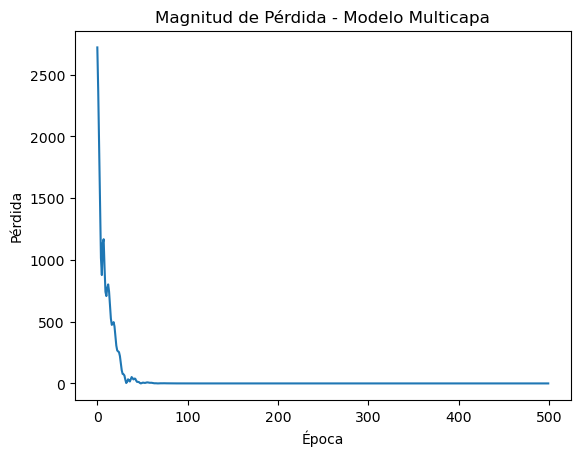

In [22]:
oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1])
oculta2 = tf.keras.layers.Dense(units=3)
salida = tf.keras.layers.Dense(units=1)

modelo_multicapa = tf.keras.Sequential([oculta1, oculta2, salida])

modelo_multicapa.compile(
    optimizer=tf.keras.optimizers.Adam(0.1),
    loss='mean_squared_error'
)

print("Entrenando modelo multicapa...")
historial_multicapa = modelo_multicapa.fit(df_temperatura['Celsius'], df_temperatura['Fahrenheit'], epochs=500, verbose=False)

plt.plot(historial_multicapa.history['loss'])
plt.title('Magnitud de Pérdida - Modelo Multicapa')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.show()

In [23]:
print("Variables internas del modelo (Pesos):")
print("Capa Oculta 1:\n", oculta1.get_weights())
print("Capa Oculta 2:\n", oculta2.get_weights())
print("Capa de Salida:\n", salida.get_weights())

Variables internas del modelo (Pesos):
Capa Oculta 1:
 [array([[-0.09897067, -0.64933157,  0.34541357]], dtype=float32), array([-3.0561862, -3.5123067, -2.1971478], dtype=float32)]
Capa Oculta 2:
 [array([[ 0.2593864 ,  0.12944157,  1.0290333 ],
       [-0.64538413,  1.4696808 ,  1.1126736 ],
       [-0.85892564,  0.38239133,  0.6075216 ]], dtype=float32), array([-1.3542298, -3.5219047, -3.4364598], dtype=float32)]
Capa de Salida:
 [array([[-0.04408179],
       [-0.9599135 ],
       [-1.631753  ]], dtype=float32), array([3.2722323], dtype=float32)]


In [24]:
valor_celsius = 100.0
prediccion = modelo_multicapa.predict(np.array([valor_celsius]))
print(f"\nPredicción: {valor_celsius} °C son {prediccion[0][0]} °F")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Predicción: 100.0 °C son 212.00003051757812 °F



## 1. El optimizador de algoritmo utilizado es Adam, pero existen otros como SGD y RMSProp, describe cada uno de ello y explica como pudieran cambiar los resultados de tu modelo.
### SGD (Stochastic Gradient Descent): Actualiza los pesos del modelo iterando sobre los datos de entrenamiento. Cambiar a SGD puede hacer que el entrenamiento sea más lento o que la función de costo oscile significativamente antes de encontrar el mínimo, haciéndolo menos eficiente que Adam para este tipo de regresión sencilla.

### RMSProp (Root Mean Square Propagation): Adapta la tasa de aprendizaje de cada parámetro dividiéndola por una media de los cuadrados de los gradientes recientes. Cambiar a RMSProp produciría resultados muy similares a Adam en cuanto a velocidad de convergencia y precisión, ya que Adam es esencialmente una combinación de RMSProp y momentum.

## 2. Describe porque es importante agregar una función de pérdida como 'mean_squared_error ', investiga que otra función de pérdida se puede implementar y como alteraría los resultados.
### Es vital agregarla porque esta función mide qué tan exacto es el modelo evaluando el error cuadrado promedio de las predicciones, permitiendo que el modelo intente minimizar este error para ajustarse en la dirección correcta durante el entrenamiento.

### Otra función de pérdida: mean_absolute_error (MAE - Error Absoluto Medio).

### Alteración de resultados: MAE penaliza todos los errores de manera lineal (proporcional), mientras que el MSE penaliza los errores de forma cuadrática (penaliza mucho más los errores grandes). Si hubiera valores atípicos (outliers) en los datos de temperatura, usar MAE haría que el modelo sea más robusto y menos sesgado por esos errores extremos.

## 3. En las modificaciones realizadas,  cuantas epocas fueron 'suficientes' para que el modelo se considere entrenado para ponerlo en funcionamiento.
### Observando el gráfico de la práctica (Progreso de Pérdida durante Entrenamiento del Modelo), la curva de pérdida cae rápidamente y se estabiliza cerca de cero en un rango de 50 a 100 épocas. A partir de las 100 épocas, la mejora es mínima o nula, por lo que esa cantidad es suficiente para considerar al modelo listo para funcionar.

## 4. ¿Por qué son importantes las epoch?
### Las épocas (epochs) son importantes porque representan las iteraciones completas que hace el algoritmo sobre todo el conjunto de entrenamiento. Determinan la cantidad de veces que el modelo ajustará sus pesos para ir disminuyendo la pérdida de sus predicciones a medida que avanza.

## 5. Que función de activación utiliza el modelo? ¿Es posible cambiarla? Si es así, cambia a una función RELU y muestra el resultado.
### El modelo actual utiliza una función de activación Lineal por defecto, ya que no se especificó ninguna dentro de la configuración de la capa:
### model.add(tf.keras.layers.Dense(units=1))

### Sí es posible cambiarla. El código modificando la capa para usar ReLU sería el siguiente:
### model.add(tf.keras.layers.Dense(units=1, activation='relu'))

### Resultado de la alteración: La función ReLU (Rectified Linear Unit) convierte cualquier valor negativo a cero. Dado que la conversión de Celsius a Fahrenheit maneja resultados negativos (ej. -40°C = -40°F), implementar ReLU arruinaría las predicciones del modelo para temperaturas bajo cero, ya que el modelo sería incapaz de devolver un resultado menor a 0.